# kairo demo

State-based process monitoring and concept-drift detection — the library behind the dashboard.
This notebook walks the three layers: **pipelines**, **plots & abstractions**, and **LLM prompting**
(local LM Studio, Anthropic, OpenAI, Google).


In [26]:
# API keys are read from the environment at call time, so load .env first (or any time before a call).
# Expected names: KAIRO_ANTHROPIC_API_KEY or ANTHROPIC_API_KEY (same pattern for OPENAI / GOOGLE).
from dotenv import find_dotenv, load_dotenv

load_dotenv(find_dotenv())

import warnings

warnings.filterwarnings("ignore")
import kairo


In [25]:
# A synthetic demo log with a sudden control-flow drift at 60% of the horizon (generated once).
from pathlib import Path

LOG_PATH = Path("../data/demo.xes")
if not LOG_PATH.exists():
    from datetime import datetime

    import rheon

    rheon.generate_log(
        [{"type": "control_flow", "mode": "sudden", "drift_point": 0.6, "num_activities": 6,
          "tree_weights": {"sequence": 0.5, "choice": 0.35, "parallel": 0.1, "loop": 0.05}}],
        str(LOG_PATH), num_traces=800, num_activities=6, num_resources=5, seed=7,
        start_date=datetime(2020, 1, 1), end_date=datetime(2020, 6, 30),
    )


## Load a log and look at it


In [27]:
log = kairo.read_log("../data/control-flow.xes")
log = kairo.map_columns(log, {
    "case ID": "case:concept:name", "activity": "concept:name",
    "timestamp": "time:timestamp", "resource": "org:resource", "event duration": None,
})
stats = kairo.log_statistics(log)
print(kairo.abstract_log_statistics(stats))


parsing log, completed traces :: 100%|████████████████████████████████████████████████████████████████████████████| 5023/5023 [00:00<00:00, 12939.07it/s]


Event log statistics:
cases: 5023, events: 28771, activities: 8, resources: 7
time span: 2020-01-01 00:30:53.004000+00:00 → 2020-12-30 21:40:58.251566+00:00 (525430 minutes)
throughput time (days): min 0.00, mean 0.15, median 0.07, max 1.80
case length (events): min 1, mean 5.7, median 3.0, max 56
activity frequencies: a (8733), b (5006), f (3865), g (3864), c (2554), d (2452), e (2143), h (154)
resource frequencies: res_05 (11827), res_02 (4022), res_06 (3894), res_03 (2887), res_07 (2743), res_04 (2542), res_01 (856)


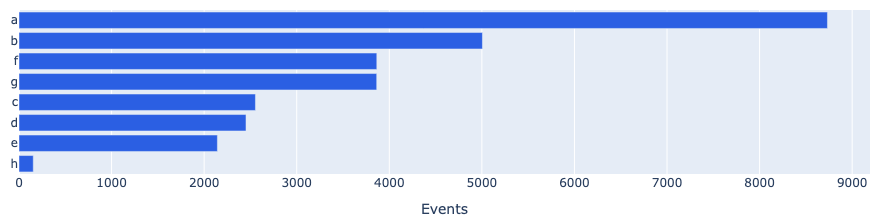

In [28]:
kairo.plot_activity_frequency(stats).show()

## Run a pipeline

One frozen config per perspective carries every parameter (features, PCA, scaling, clustering,
windows). `run_intra_case` / `run_resource` / `run_inter_case` return a `StateResult` holding
everything: features, PCA, states, trajectories, transitions, distribution, drift signal.


In [36]:
config = kairo.IntraConfig(
    features=("activity_freq", "bigram", "vocab", "progress", "current", "history"),
    clustering="som", grid=(5, 5), metric="euclidean",
    pca_components=8, window_minutes=1440 * 3,   # 3-day distribution windows
    divergence="kl"
)
result = kairo.run_intra_case(log, config)
result.to_dict()


{'perspective': 'intra_case',
 'config': {'features': ('activity_freq',
   'bigram',
   'vocab',
   'progress',
   'current',
   'history'),
  'history': 3,
  'skip_pca': False,
  'pca_components': 8,
  'scaling': 'none',
  'clustering': 'som',
  'metric': 'euclidean',
  'grid': (5, 5),
  'som_init': 'random',
  'n_clusters': 6,
  'eps': 0.5,
  'min_samples': 5,
  'window_minutes': 4320,
  'divergence': 'kl',
  'reference': 'previous',
  'lookback': 5,
  'seed': 7},
 'rows': 28771,
 'feature_columns': 68,
 'pca_components': 8,
 'n_states': 25,
 'method': 'som',
 'transitions': 23748,
 'windows': 122}

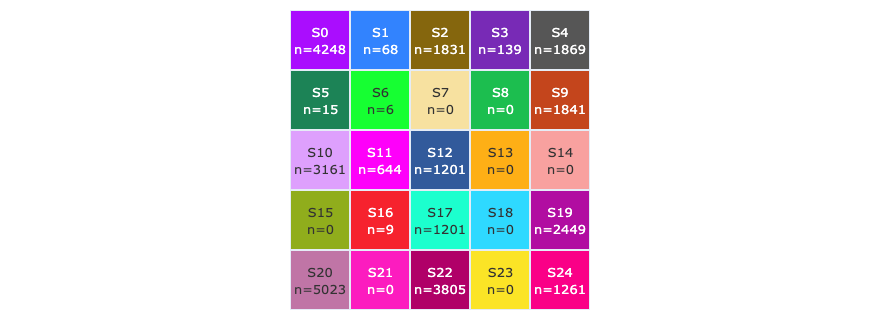

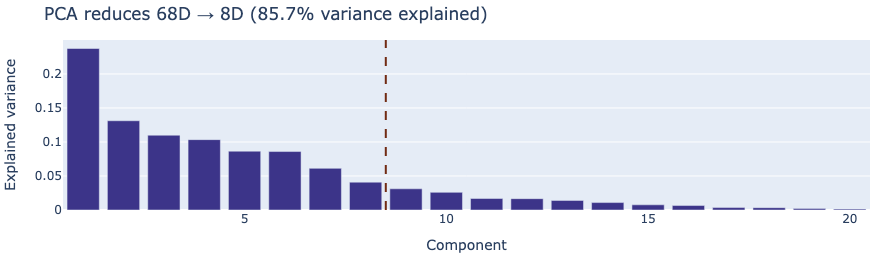

In [37]:
kairo.plot_state_grid(result.states).show()
kairo.plot_pca_variance(result.pca).show()


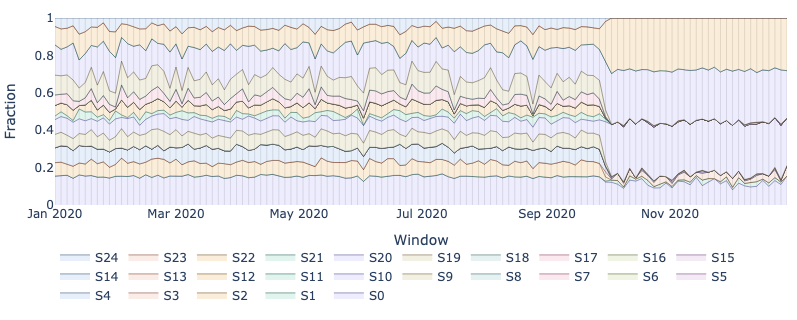

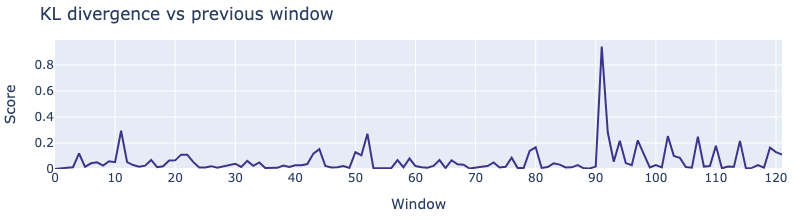

In [39]:
dist_fig = kairo.plot_state_distribution(result.distribution, result.states)
kairo.add_window_boundaries(dist_fig, result.distribution["window_start"])
dist_fig.show()
signal_fig = kairo.plot_drift_signal(result.signal, title="KL divergence vs previous window")
signal_fig.show()   # the drift point at 60% should stand out


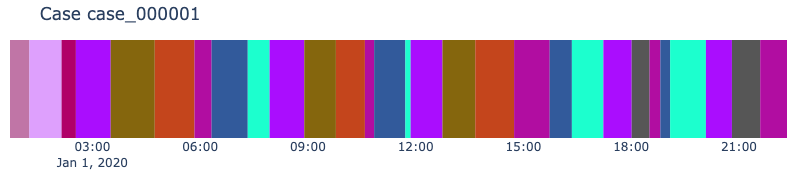

In [40]:
# One case's trajectory through the states
case = result.trajectories["case:concept:name"].iloc[1]
sub = result.trajectories[result.trajectories["case:concept:name"] == case]
kairo.plot_trajectory(sub["time:timestamp"], sub["state_id"].to_numpy(), result.states,
                      title=f"Case {case}").show()


### Step-by-step instead of the runner

Every step is its own function with the same parameter granularity, so an analysis (or an agent)
can hold and inspect the intermediates.


(365, 7) features -> (365, 3) reduced -> 4 states, silhouette 0.28


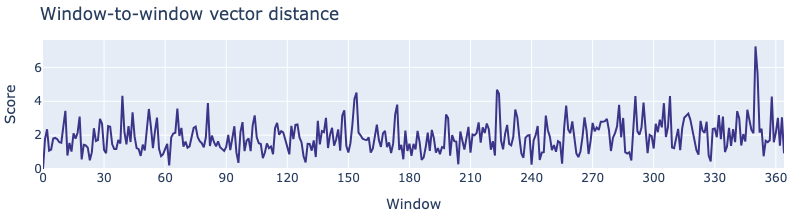

In [41]:
fs = kairo.features.build_features(log, "inter_case", window_minutes=1440)
reduced, pca = kairo.analysis.reduce(fs.values(), n_components=3, scaling="standardize")
model = kairo.analysis.cluster_kmeans(reduced, n_clusters=4)
shift = kairo.analysis.window_vector_shift(fs.index["window_start"], reduced)
print(f"{fs.matrix.shape} features -> {reduced.shape} reduced -> {model.n_states} states, "
      f"silhouette {kairo.analysis.silhouette(reduced, model):.2f}")
kairo.plot_drift_signal(shift, title="Window-to-window vector distance").show()


## Abstractions: everything as text

Each computed object has an `abstract_*` twin that renders it for a prompt — no network involved.
`abstract_result` composes them all under one length budget.


In [42]:
profiles = kairo.analysis.state_profiles(result.features, result.states)
print(kairo.abstract_states(result.states, profiles=profiles, max_len=1200))


States from som (5×5 grid), parameters {'grid': (5, 5), 'metric': 'euclidean', 'init': 'random', 'epochs': 5, 'seed': 7}:
- S0: 4248 samples (14.8%), dominant: e
- S1: 68 samples (0.2%), dominant: d
- S2: 1831 samples (6.4%), dominant: f
- S3: 139 samples (0.5%), dominant: h
- S4: 1869 samples (6.5%), dominant: g
- S5: 15 samples (0.1%), dominant: h
- S6: 6 samples (0.0%), dominant: h
- S7: 0 samples (0.0%)
- S8: 0 samples (0.0%)
- S9: 1841 samples (6.4%), dominant: g
- S10: 3161 samples (11.0%), dominant: b
- S11: 644 samples (2.2%), dominant: b
- S12: 1201 samples (4.2%), dominant: b
- S13: 0 samples (0.0%)
- S14: 0 samples (0.0%)
- S15: 0 samples (0.0%)
- S16: 9 samples (0.0%), dominant: d
- S17: 1201 samples (4.2%), dominant: c
- S18: 0 samples (0.0%)
- S19: 2449 samples (8.5%), dominant: a
- S20: 5023 samples (17.5%), dominant: a
- S21: 0 samples (0.0%)
- S22: 3805 samples (13.2%), dominant: c
- S23: 0 samples (0.0%)
- S24: 1261 samples (4.4%), dominant: a
Distinguishing features 

In [43]:
print(kairo.abstract_result(result, max_len=3000))


=== intra_case pipeline run ===

IntraConfig parameters:
- features: ('activity_freq', 'bigram', 'vocab', 'progress', 'current', 'history')
- history: 3
- skip_pca: False
- pca_components: 8
- scaling: none
- clustering: som
- metric: euclidean
- grid: (5, 5)
- som_init: random
- n_clusters: 6
- eps: 0.5
- min_samples: 5
- window_minutes: 4320
- divergence: kl
- reference: previous
- lookback: 5
- seed: 7

intra_case feature matrix: 28771 rows × 68 columns.
- activity_freq (Activity frequencies): 8 columns
- bigram (Directly-follows counts): 19 columns
- vocab (Distinct activity set): 8 columns
- progress (Case progress): 1 columns
- current (Current activity): 8 columns
- history (Past activities): 24 columns
Column ranges (min → max, mean):
  activity_freq:a: 0.167 → 1.000, mean 0.403
  activity_freq:b: 0.000
... [truncated]

PCA reduced 68 feature columns to 8 components (85.7% of variance).
Explained variance per component: PC1=0.237, PC2=0.131, PC3=0.110, PC4=0.103, PC5=0.086, PC6

## Ask an LLM about the analysis

`kairo.ask` builds a prompt from injected domain knowledge (drift detection, process mining,
the method, statistics), the log, and the abstracted result — then executes it with any connector.
The `executor` is just a callable, so every provider (or your own function) plugs in the same way.


In [44]:
# Inspect the prompt without any network call:
prompt = kairo.build_prompt("Where does the process drift, and what changes?",
                                result=result, log=log)
print(prompt[:1500], "…")


<knowledge>
The analysis studies state-based concept drift detection in traditional event logs.
A process is monitored through three complementary notions of state:
- Intra-case state: the situation of one running case, derived from its event prefix
  (executed activities, their order, position in the case).
- Resource state: how the resource dimension behaves across all cases in a calendar
  window (workload, handovers, waiting times, activity-resource assignments).
- Inter-case state: the global process situation per calendar window (active cases,
  arrivals, completions, pacing, stalled cases, case-attribute mixes).
Concept drift means the underlying process changed over time. The core idea: compute
states by clustering feature vectors, follow how state occupancy evolves over calendar
windows, and read significant changes in those state signals as drift indicators.
A good analysis names WHERE the signal spikes (which windows), WHAT changed (which
states grew or shrank, which feature

In [45]:
QUESTION = "Does this analysis show concept drift? Name the windows, the states involved, and your confidence."


### Local model via LM Studio

Start LM Studio, load a model, and enable the local server (default `http://localhost:1234/v1`).
With `model=None` kairo picks the first loaded model automatically. Ollama works the same way
with `api_url="http://localhost:11434/v1"`.


In [46]:
print(kairo.llm.available_models("local"))


['google/gemma-4-e4b', 'meta/llama-3.3-70b', 'text-embedding-nomic-embed-text-v1.5']


In [47]:
answer = kairo.ask(QUESTION, result=result, log=log, executor=kairo.local_query)
print(answer)


Based on the analysis, **yes, there is strong evidence of concept drift.**

The divergence signal exhibits multiple sharp spikes significantly above the baseline average, indicating that the underlying process state changed abruptly at several specific points in time.

---

### 1. Concept Drift Confirmation and Confidence

*   **Drift Indication:** Significant concept drift is present.
*   **Evidence Metric:** The maximum divergence score achieved was **0.942**, which is dramatically higher than the mean baseline divergence of **0.061**. This large deviation confirms that, at minimum, one window (Window 91) represents a substantial and rapid shift in process behavior compared to the preceding time period.
*   **Type of Drift:** Since the changes manifest as distinct, high spikes followed by immediate drops back toward lower scores, the primary type of drift indicated is **Sudden Concept Drift**.

### 2. Where (The Spiking Windows)

Concept drift was detected in five highly significant 

### Hosted providers


In [19]:
answer = kairo.ask(QUESTION, result=result, log=log,
                       executor=kairo.anthropic_query, model="claude-sonnet-5")
print(answer)


## Short answer: Weak-to-moderate evidence of drift, concentrated late in the log

The signal is mostly flat and low (mean 0.026, most windows well under 0.05), which means for the majority of the ~6-month period the mix of intra-case states (S0/a, S2/b, S3/a-variant, S4/e, S5/b-variant, S6/d, S8/c — note S1 and S7 are empty, so effectively 7 active SOM cells, not 9) stays stable from one 3-day window to the next. Against that flat background, two things stand out:

**Where it spikes**
- A single isolated bump at **window 4** (2020-01-13, score 0.063) — comparable in size to several other one-off bumps scattered through the middle of the log (window 10–11: 0.044–0.047, window 22: 0.044, window 26: 0.060, window 36: 0.059, window 43: 0.049). These are all single-window spikes against a *previous-window* reference that immediately relax back to baseline — the classic signature of local noise or very small sudden jumps, not a sustained regime change.
- A **cluster of elevated scores at th

In [ ]:
# Same call, different connector:
# kairo.ask(QUESTION, result=result, executor=kairo.openai_query, model="gpt-5")
# kairo.ask(QUESTION, result=result, executor=kairo.google_query, model="gemini-2.5-flash")
# kairo.query("ping", provider="openai")  # provider dispatch without an executor


### Explain a plot

`explain_plot` renders any kairo figure to an image and sends it to a vision-capable model.


In [ ]:
explanation = kairo.explain_plot(signal_fig, "What does this drift signal show? Where would you place the drift?",
                                     result=result, executor=kairo.anthropic_query)
print(explanation)


### Natural language → pipeline config

`nlp_to_config` turns a request into a validated config dataclass — the seam for agentic loops:
propose a config, run it, read `abstract_result`, propose the next one.


In [21]:
cfg = kairo.nlp_to_config(
    "look for drift at weekly granularity with DBSCAN and a fairly tight eps, cosine distance",
    perspective="intra_case", executor=kairo.anthropic_query,
)
print(cfg)
kairo.run_intra_case(log, cfg)  # …and run it


IntraConfig(features=('activity_freq', 'bigram', 'vocab', 'progress', 'current', 'history'), history=3, skip_pca=False, pca_components=None, scaling='none', clustering='dbscan', metric='cosine', grid=(3, 3), som_init='random', n_clusters=6, eps=0.3, min_samples=5, window_minutes=10080, divergence='js', reference='previous', lookback=5, seed=7)


---
Full documentation: open `kairo/index.html`. The dashboard uses exactly these functions —
`streamlit run dashboard/app.py`.
